# Score

This notebook summarizes alignment quality for each generated model against all same-document peer models, then aggregates the results by scenario slices such as `control`, `guided`, and future conditions like `feedback` automatically.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import JSON, display

from src.lib.align_pipeline import (
    build_feedback_delta_frame,
    build_feedback_target_delta_frame,
    load_alignment_candidates,
    load_project_artifacts,
    score_alignment_candidates,
    write_score_outputs,
)
from src.lib.infer_pipeline import find_repo_root

pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
sns.set_theme(style="whitegrid", context="notebook")
repo_root = find_repo_root()

In [2]:
model_index, elements = load_project_artifacts(repo_root)
candidates = load_alignment_candidates(repo_root)
scenario_values = sorted(model_index["condition"].astype(str).unique().tolist())
snapshot = {
    "model_count": int(len(model_index)),
    "element_count": int(len(elements)),
    "candidate_count": int(len(candidates)),
    "scenarios": scenario_values,
    "documents": sorted(model_index["source_document_id"].astype(str).unique().tolist()),
    "backends": sorted(candidates["backend"].astype(str).unique().tolist()),
    "methods": sorted(candidates["method"].astype(str).unique().tolist()),
}
display(JSON(snapshot, expanded=True))

<IPython.core.display.JSON object>

In [3]:
pair_scores, model_scores, scenario_scores, scenario_matrix_scores = (
    score_alignment_candidates(model_index, elements, candidates)
)
score_summary = write_score_outputs(
    repo_root,
    pair_scores,
    model_scores,
    scenario_scores,
    scenario_matrix_scores,
)
display(JSON(score_summary, expanded=True))

<IPython.core.display.JSON object>

In [4]:
scenario_matrix_pivot = (
    scenario_matrix_scores.pivot_table(
        index=[
            "source_document_id",
            "projection_layer",
            "projection_mode",
            "backend",
            "method",
            "source_condition",
        ],
        columns="target_condition",
        values="mean_pair_alignment_score",
        aggfunc="mean",
    )
    .reset_index()
)

In [5]:
primary_metric = "mean_pair_alignment_f1"
scenario_method_scores = (
    scenario_scores.assign(
        method_label=lambda df: df["backend"].astype(str) + ":" + df["method"].astype(str)
    )
    .groupby(
        ["source_condition", "projection_layer", "method_label"],
        dropna=False,
    )
    .agg(mean_metric=(primary_metric, "mean"))
    .reset_index()
)
feedback_delta = build_feedback_delta_frame(
    model_scores,
    metric_column=primary_metric,
)
feedback_target_delta = build_feedback_target_delta_frame(
    scenario_matrix_scores,
    metric_column=primary_metric,
)
feedback_method_summary = (
    feedback_delta.assign(
        method_label=lambda df: df["backend"].astype(str) + ":" + df["method"].astype(str)
    )
    .groupby(["projection_layer", "projection_mode", "method_label"], dropna=False)
    .agg(
        comparable_slice_count=("source_document_id", "count"),
        mean_feedback_minus_control=("feedback_minus_control", "mean"),
        mean_feedback_minus_guided=("feedback_minus_guided", "mean"),
        feedback_best_rate=("feedback_is_best", "mean"),
    )
    .reset_index()
    .sort_values(
        ["mean_feedback_minus_guided", "mean_feedback_minus_control", "method_label"],
        ascending=[False, False, True],
        ignore_index=True,
    )
)
feedback_target_summary = (
    feedback_target_delta.assign(
        method_label=lambda df: df["backend"].astype(str) + ":" + df["method"].astype(str)
    )
    .groupby(
        ["projection_layer", "projection_mode", "target_condition", "method_label"],
        dropna=False,
    )
    .agg(
        comparable_slice_count=("source_document_id", "count"),
        mean_feedback_minus_control=("feedback_minus_control", "mean"),
        mean_feedback_minus_guided=("feedback_minus_guided", "mean"),
    )
    .reset_index()
)
producer_points = pair_scores.assign(
    plot_score=lambda df: df["pair_alignment_f1"],
    y_level=lambda df: (
        df["source_producer_id"].astype(str) + " | " + df["source_condition"].astype(str)
    ),
)
producer_level_means = (
    producer_points.groupby(
        ["projection_layer", "source_producer_id", "source_condition", "y_level"],
        dropna=False,
    )
    .agg(level_mean_score=("plot_score", "mean"))
    .reset_index()
)
display({
    "scenario_method_rows": int(len(scenario_method_scores)),
    "feedback_delta_rows": int(len(feedback_delta)),
    "feedback_target_delta_rows": int(len(feedback_target_delta)),
    "producer_point_rows": int(len(producer_points)),
    "producer_level_mean_rows": int(len(producer_level_means)),
})
display(feedback_delta.head(20))
display(feedback_target_delta.head(20))
display(feedback_method_summary.head(20))

{'scenario_method_rows': 95,
 'feedback_delta_rows': 665,
 'feedback_target_delta_rows': 670,
 'producer_point_rows': 13165,
 'producer_level_mean_rows': 27}

,source_document_id,source_producer_id,projection_layer,projection_mode,backend,method,control,feedback,guided,feedback_minus_control,feedback_minus_guided,guided_minus_control,best_condition,feedback_is_best
0,framework-laptop-13-specs,google/gemini-2.5-flash-lite,type,members_as_values,bdikit,cupid,0.737963,0.706985,0.123136,-0.030978,0.583849,-0.614827,control,False
1,github-create-issue-api,mistralai/ministral-3b-2512,relation,path_plus_metadata_values,valentine,distribution_based,NaN,0.865637,0.409758,NaN,0.455879,NaN,feedback,True
2,framework-laptop-13-specs,meta-llama/llama-3.2-3b-instruct,type,members_as_values,valentine,distribution_based,0.264194,0.624358,0.286225,0.360164,0.338133,0.022031,feedback,True
3,ikea-billy-mainual,mistralai/ministral-3b-2512,property,path_plus_metadata_values,valentine,distribution_based,0.732607,0.863093,0.575120,0.130487,0.287973,-0.157487,feedback,True
4,standard-fragment,google/gemini-2.5-flash-lite,relation,path_plus_metadata_values,valentine,cupid,0.490731,0.562558,0.349011,0.071828,0.213547,-0.141720,feedback,True
5,king-arthur-pancakes,google/gemini-2.5-flash-lite,type,members_as_values,bdikit,cupid,0.312939,0.747438,0.547598,0.434499,0.199840,0.234659,feedback,True
6,king-arthur-pancakes,google/gemini-2.5-flash-lite,relation,path_plus_metadata_values,bdikit,distribution_based,0.166667,0.186305,0.000000,0.019638,0.186305,-0.166667,feedback,True
7,ikea-billy-mainual,meta-llama/llama-3.2-3b-instruct,relation,path_plus_metadata_values,valentine,distribution_based,NaN,0.444444,0.279528,NaN,0.164917,NaN,feedback,True
8,standard-fragment,google/gemini-2.5-flash-lite,relation,path_plus_metadata_values,bdikit,cupid,0.490731,0.752894,0.604515,0.262164,0.148379,0.113785,feedback,True
9,ikea-billy-mainual,meta-llama/llama-3.2-3b-instruct,property,path_plus_metadata_values,bdikit,distribution_based,NaN,0.875816,0.728975,NaN,0.146841,NaN,feedback,True


,source_document_id,target_condition,projection_layer,projection_mode,backend,method,control,feedback,guided,feedback_minus_control,feedback_minus_guided,guided_minus_control
0,king-arthur-pancakes,feedback,relation,path_plus_metadata_values,bdikit,distribution_based,0.000000,0.661536,0.000000,0.661536,0.661536,0.000000
1,github-create-issue-api,guided,relation,path_plus_metadata_values,valentine,distribution_based,0.909091,0.558985,0.181818,-0.350106,0.377167,-0.727273
2,stripe-payment-intent,guided,relation,path_plus_metadata_values,valentine,coma_py,0.355523,0.676786,0.342845,0.321264,0.333941,-0.012678
3,framework-laptop-13-specs,guided,type,members_as_values,bdikit,cupid,0.603562,0.510115,0.213092,-0.093447,0.297024,-0.390470
4,framework-laptop-13-specs,guided,relation,path_plus_metadata_values,valentine,distribution_based,NaN,0.378778,0.121212,NaN,0.257566,NaN
5,stripe-payment-intent,guided,relation,path_plus_metadata_values,bdikit,coma,0.620422,0.676786,0.428556,0.056365,0.248230,-0.191865
6,stripe-payment-intent,guided,relation,path_plus_metadata_values,bdikit,jaccard_distance,0.455556,0.505556,0.277778,0.050000,0.227778,-0.177778
7,framework-laptop-13-specs,guided,type,members_as_values,valentine,cupid,0.155055,0.285536,0.065567,0.130480,0.219969,-0.089489
8,ikea-billy-mainual,guided,type,members_as_values,bdikit,distribution_based,0.216553,0.447184,0.238526,0.230632,0.208658,0.021973
9,ikea-billy-mainual,guided,property,path_plus_metadata_values,valentine,distribution_based,0.774546,0.841613,0.636508,0.067067,0.205106,-0.138039


,projection_layer,projection_mode,method_label,comparable_slice_count,mean_feedback_minus_control,mean_feedback_minus_guided,feedback_best_rate
0,property,path_plus_metadata_values,valentine:distribution_based,12,0.018494,0.063580,0.416667
1,type,members_as_values,bdikit:cupid,18,0.039306,0.029386,0.277778
2,relation,path_plus_metadata_values,valentine:distribution_based,14,-0.109953,0.020269,0.214286
3,type,members_as_values,valentine:cupid,18,0.103242,0.016728,0.555556
4,property,path_plus_metadata_values,bdikit:distribution_based,12,0.047094,0.011300,0.250000
5,relation,path_plus_metadata_values,valentine:coma_py,17,0.057838,0.009098,0.352941
6,type,members_as_values,bdikit:similarity_flooding,18,0.016329,0.005178,0.388889
7,type,members_as_values,valentine:similarity_flooding,18,0.033372,0.004979,0.388889
8,property,path_only,bdikit:distribution_based,18,0.000000,0.000000,0.000000
9,property,path_only,bdikit:jaccard_distance,18,0.000000,0.000000,0.000000


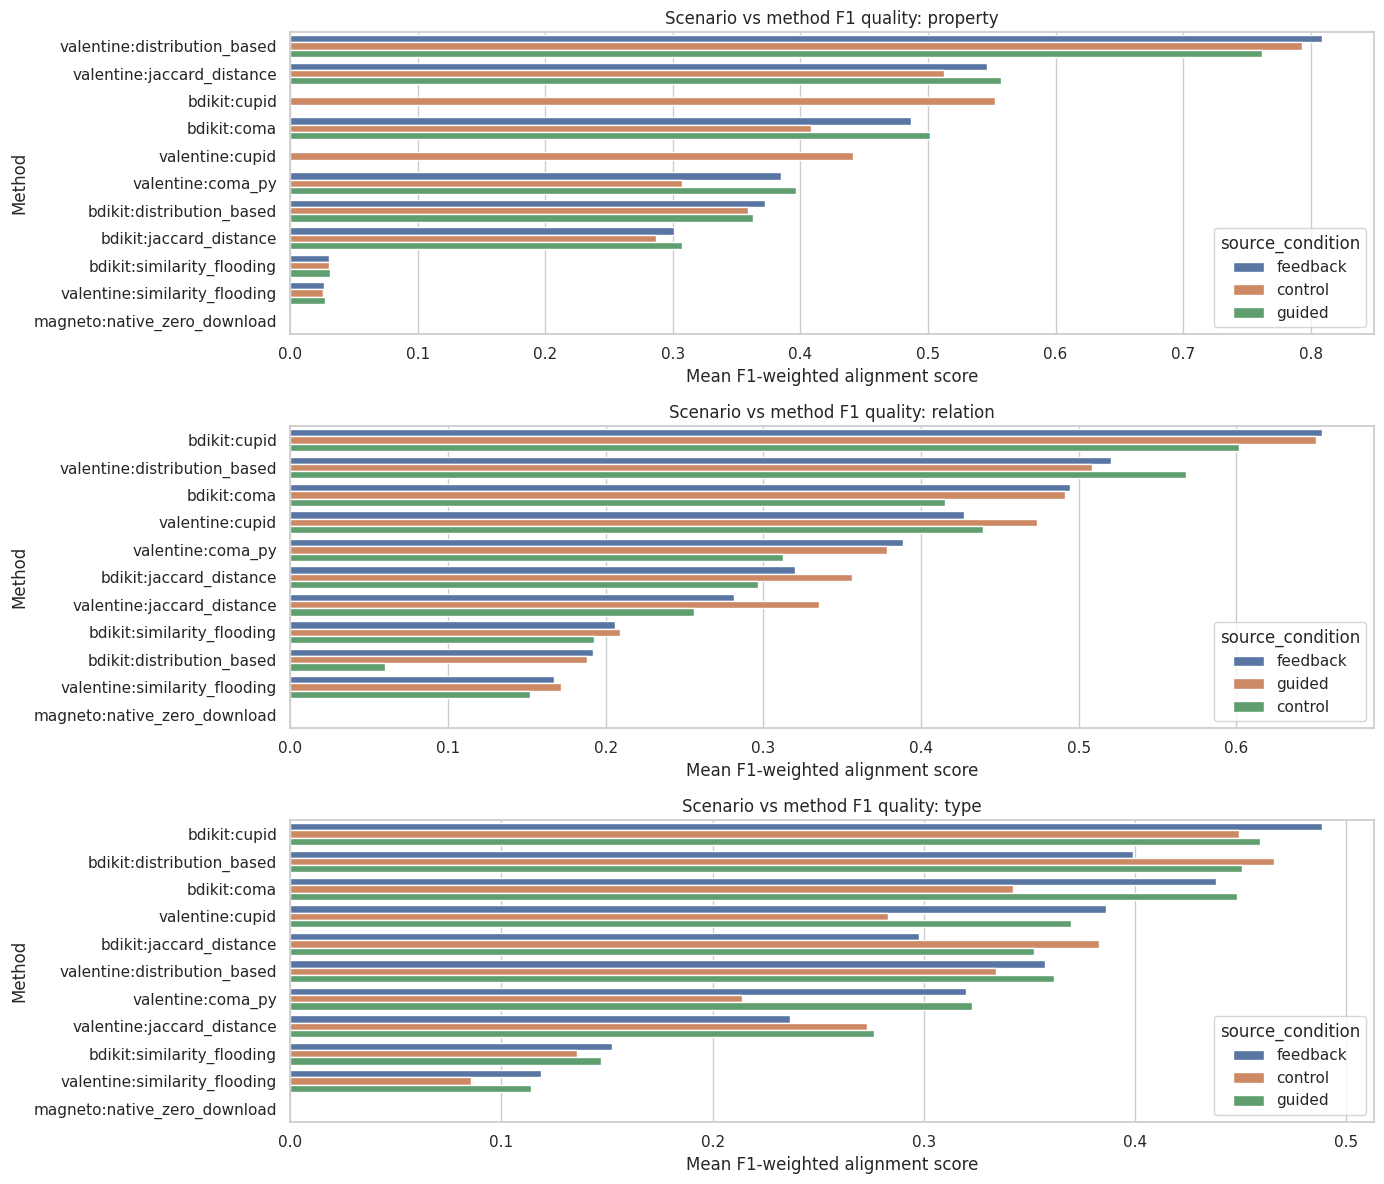

In [6]:
layer_order = sorted(scenario_method_scores["projection_layer"].astype(str).unique().tolist())
fig, axes = plt.subplots(
    nrows=len(layer_order),
    ncols=1,
    figsize=(14, 4 * max(len(layer_order), 1)),
    squeeze=False,
)

for axis, layer in zip(axes.flat, layer_order, strict=True):
    layer_frame = scenario_method_scores[
        scenario_method_scores["projection_layer"] == layer
    ].copy()
    layer_frame = layer_frame.sort_values(
        ["mean_metric", "method_label"],
        ascending=[False, True],
        ignore_index=True,
    )
    sns.barplot(
        data=layer_frame,
        x="mean_metric",
        y="method_label",
        hue="source_condition",
        orient="h",
        ax=axis,
    )
    axis.set_title(f"Scenario vs method F1 quality: {layer}")
    axis.set_xlabel("Mean F1-weighted alignment score")
    axis.set_ylabel("Method")

plt.tight_layout()
plt.show()

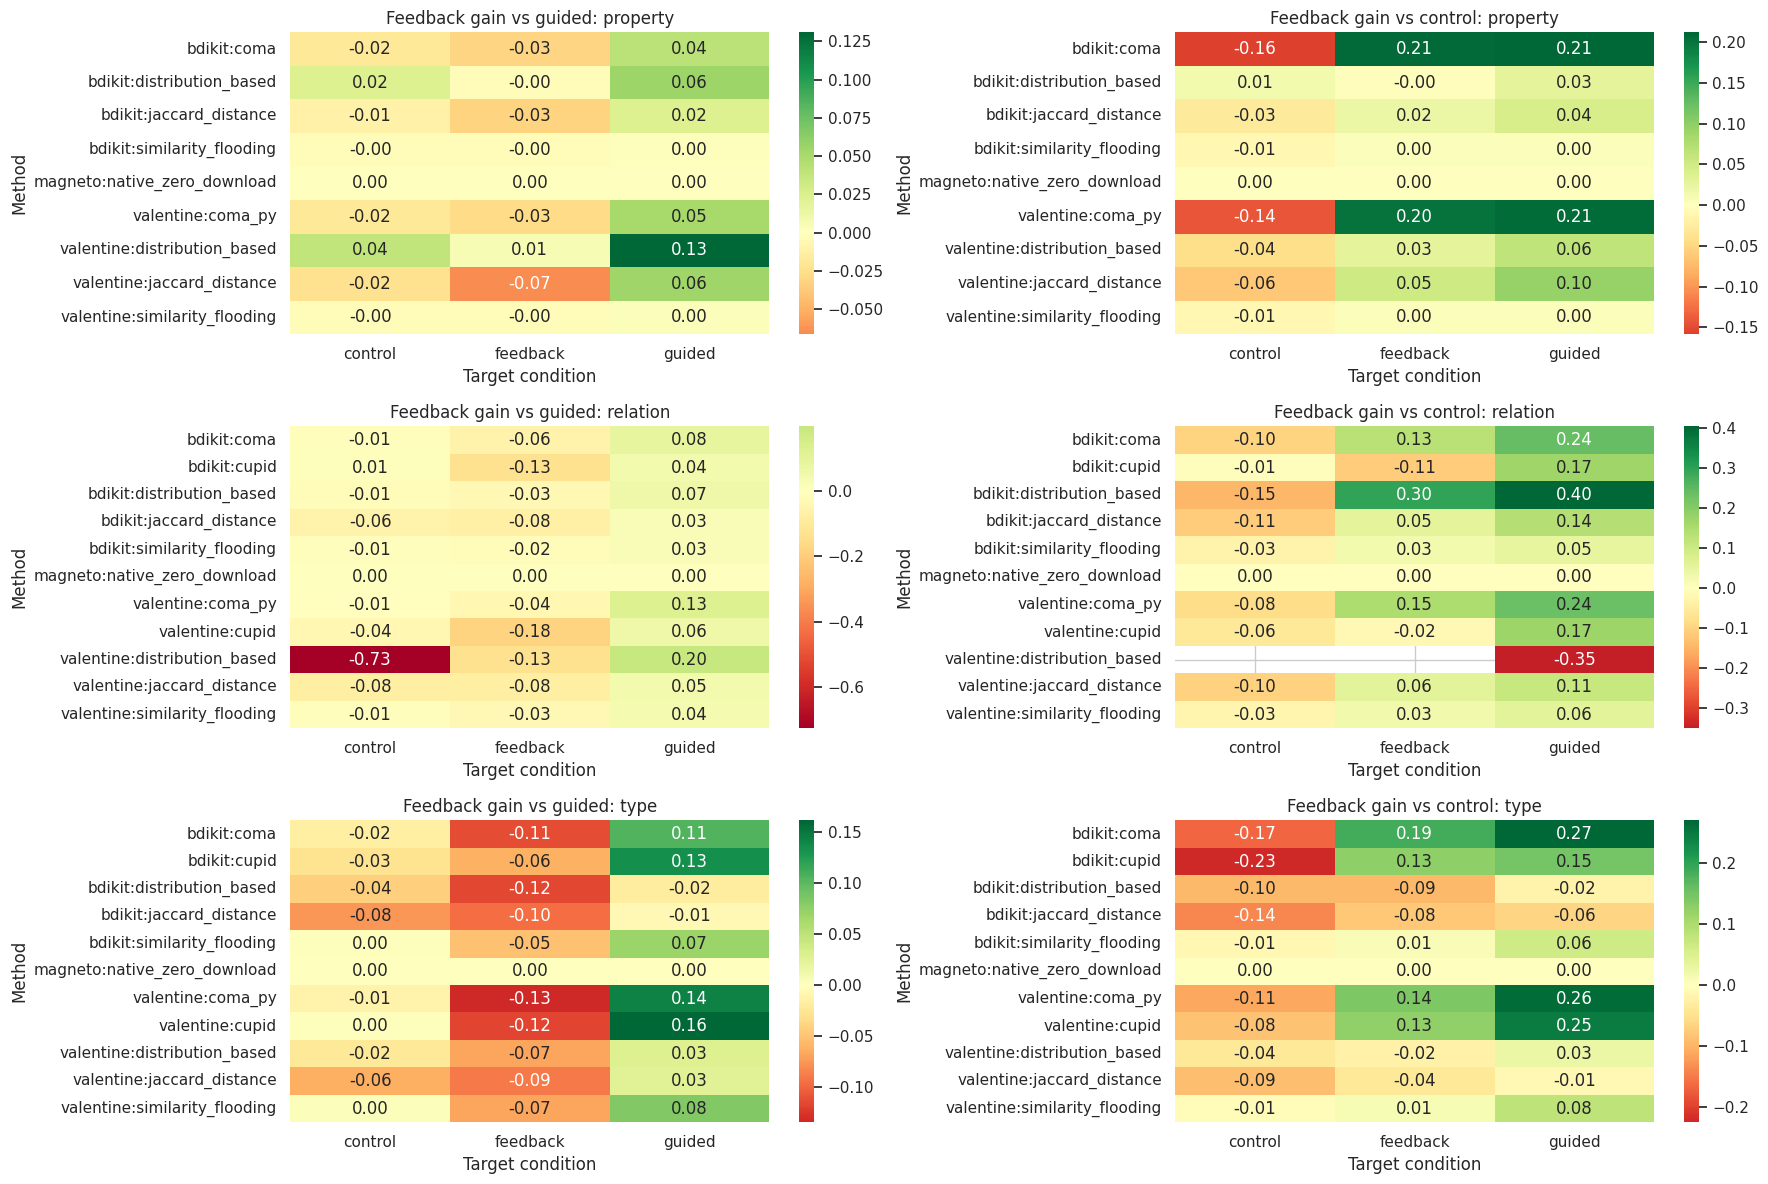

In [7]:
layer_order = sorted(feedback_target_summary["projection_layer"].astype(str).unique().tolist())
fig, axes = plt.subplots(
    nrows=len(layer_order),
    ncols=2,
    figsize=(18, 4 * max(len(layer_order), 1)),
    squeeze=False,
)

for row_index, layer in enumerate(layer_order):
    layer_frame = feedback_target_summary[
        feedback_target_summary["projection_layer"] == layer
    ]
    guided_heatmap = layer_frame.pivot_table(
        index="method_label",
        columns="target_condition",
        values="mean_feedback_minus_guided",
        aggfunc="mean",
    )
    control_heatmap = layer_frame.pivot_table(
        index="method_label",
        columns="target_condition",
        values="mean_feedback_minus_control",
        aggfunc="mean",
    )
    sns.heatmap(
        guided_heatmap,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        center=0.0,
        ax=axes[row_index, 0],
    )
    axes[row_index, 0].set_title(f"Feedback gain vs guided: {layer}")
    axes[row_index, 0].set_xlabel("Target condition")
    axes[row_index, 0].set_ylabel("Method")
    sns.heatmap(
        control_heatmap,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        center=0.0,
        ax=axes[row_index, 1],
    )
    axes[row_index, 1].set_title(f"Feedback gain vs control: {layer}")
    axes[row_index, 1].set_xlabel("Target condition")
    axes[row_index, 1].set_ylabel("Method")

plt.tight_layout()
plt.show()

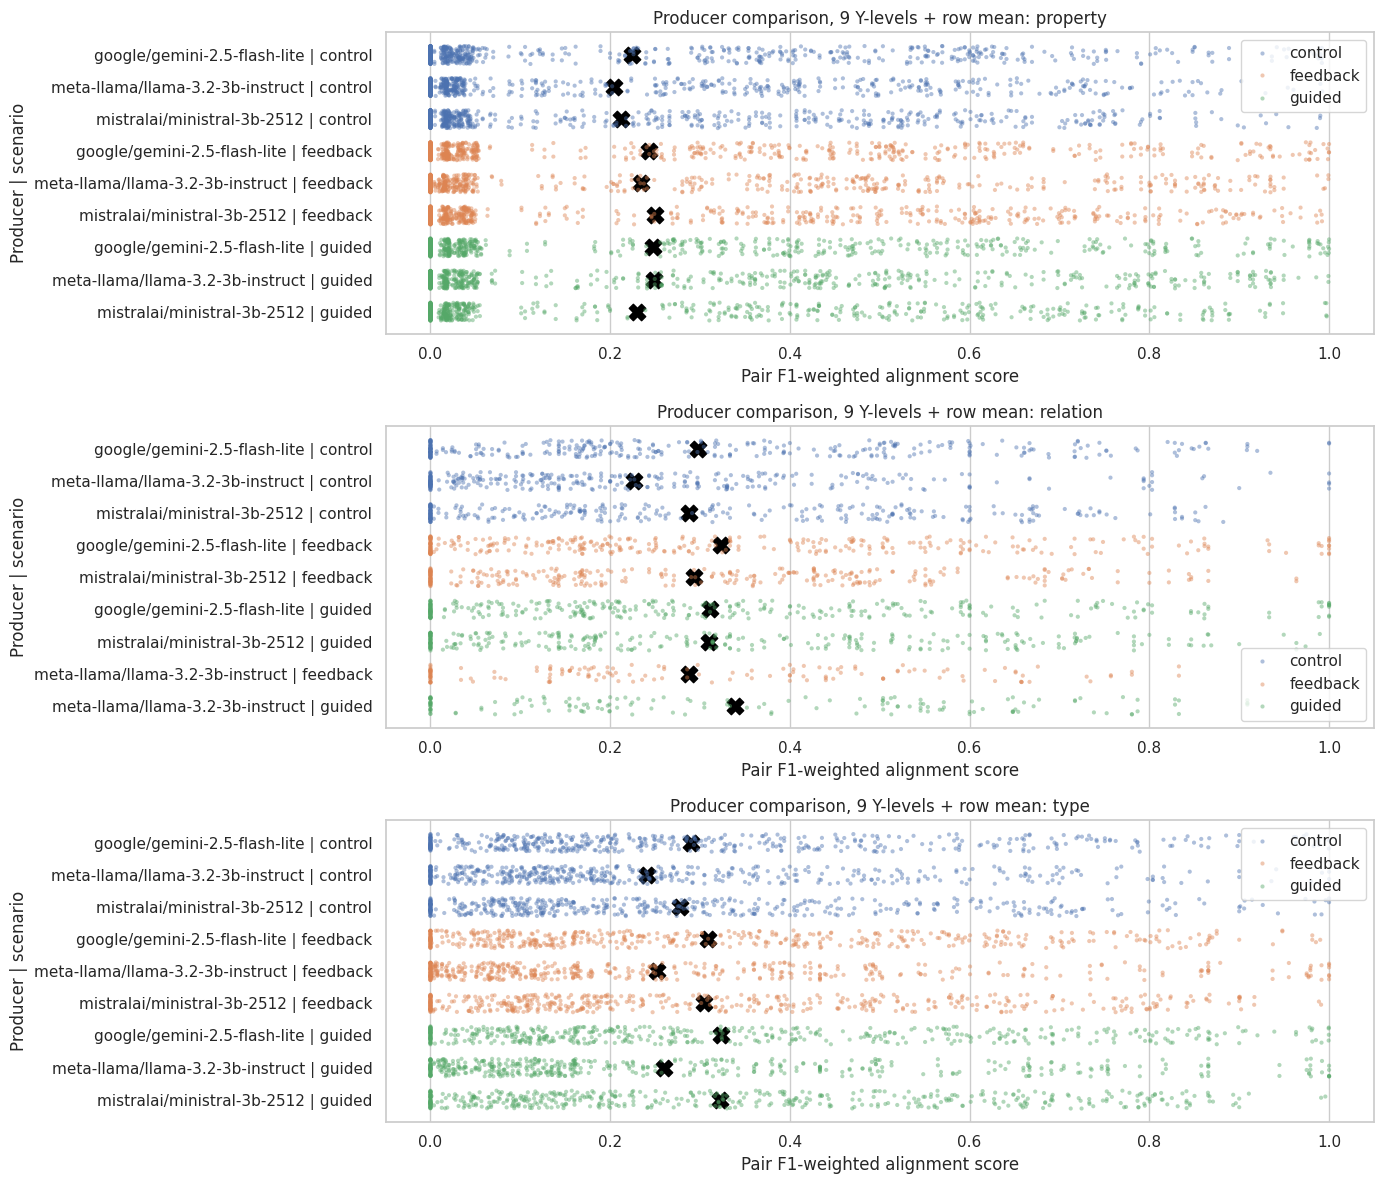

In [8]:
producer_points = pair_scores.assign(
    plot_score=lambda df: df["pair_alignment_f1"],
    y_level=lambda df: (
        df["source_producer_id"].astype(str) + " | " + df["source_condition"].astype(str)
    ),
)
producer_level_means = (
    producer_points.groupby(
        ["projection_layer", "source_producer_id", "source_condition", "y_level"],
        dropna=False,
    )
    .agg(level_mean_score=("plot_score", "mean"))
    .reset_index()
)

layer_order = sorted(producer_points["projection_layer"].astype(str).unique().tolist())
fig, axes = plt.subplots(
    nrows=len(layer_order),
    ncols=1,
    figsize=(14, 4 * max(len(layer_order), 1)),
    squeeze=False,
)

for axis, layer in zip(axes.flat, layer_order, strict=True):
    layer_frame = producer_points[
        producer_points["projection_layer"] == layer
    ].copy()
    mean_frame = producer_level_means[
        producer_level_means["projection_layer"] == layer
    ].copy()
    sns.stripplot(
        data=layer_frame,
        x="plot_score",
        y="y_level",
        hue="source_condition",
        dodge=False,
        jitter=0.28,
        size=3,
        alpha=0.45,
        linewidth=0,
        ax=axis,
    )
    sns.scatterplot(
        data=mean_frame,
        x="level_mean_score",
        y="y_level",
        color="black",
        marker="X",
        s=140,
        edgecolor="black",
        linewidth=1.0,
        ax=axis,
    )
    axis.set_title(f"Producer comparison, 9 Y-levels + row mean: {layer}")
    axis.set_xlabel("Pair F1-weighted alignment score")
    axis.set_ylabel("Producer | scenario")

plt.tight_layout()
plt.show()

{'same_scenario_rows': 1140,
 'documents': ['framework-laptop-13-specs',
  'github-create-issue-api',
  'ikea-billy-mainual',
  'king-arthur-pancakes',
  'standard-fragment',
  'stripe-payment-intent'],
 'model_pair_order': ['google/gemini-2.5-flash-lite -> google/gemini-2.5-flash-lite',
  'google/gemini-2.5-flash-lite -> meta-llama/llama-3.2-3b-instruct',
  'google/gemini-2.5-flash-lite -> mistralai/ministral-3b-2512',
  'meta-llama/llama-3.2-3b-instruct -> google/gemini-2.5-flash-lite',
  'meta-llama/llama-3.2-3b-instruct -> meta-llama/llama-3.2-3b-instruct',
  'meta-llama/llama-3.2-3b-instruct -> mistralai/ministral-3b-2512',
  'mistralai/ministral-3b-2512 -> google/gemini-2.5-flash-lite',
  'mistralai/ministral-3b-2512 -> meta-llama/llama-3.2-3b-instruct',
  'mistralai/ministral-3b-2512 -> mistralai/ministral-3b-2512']}

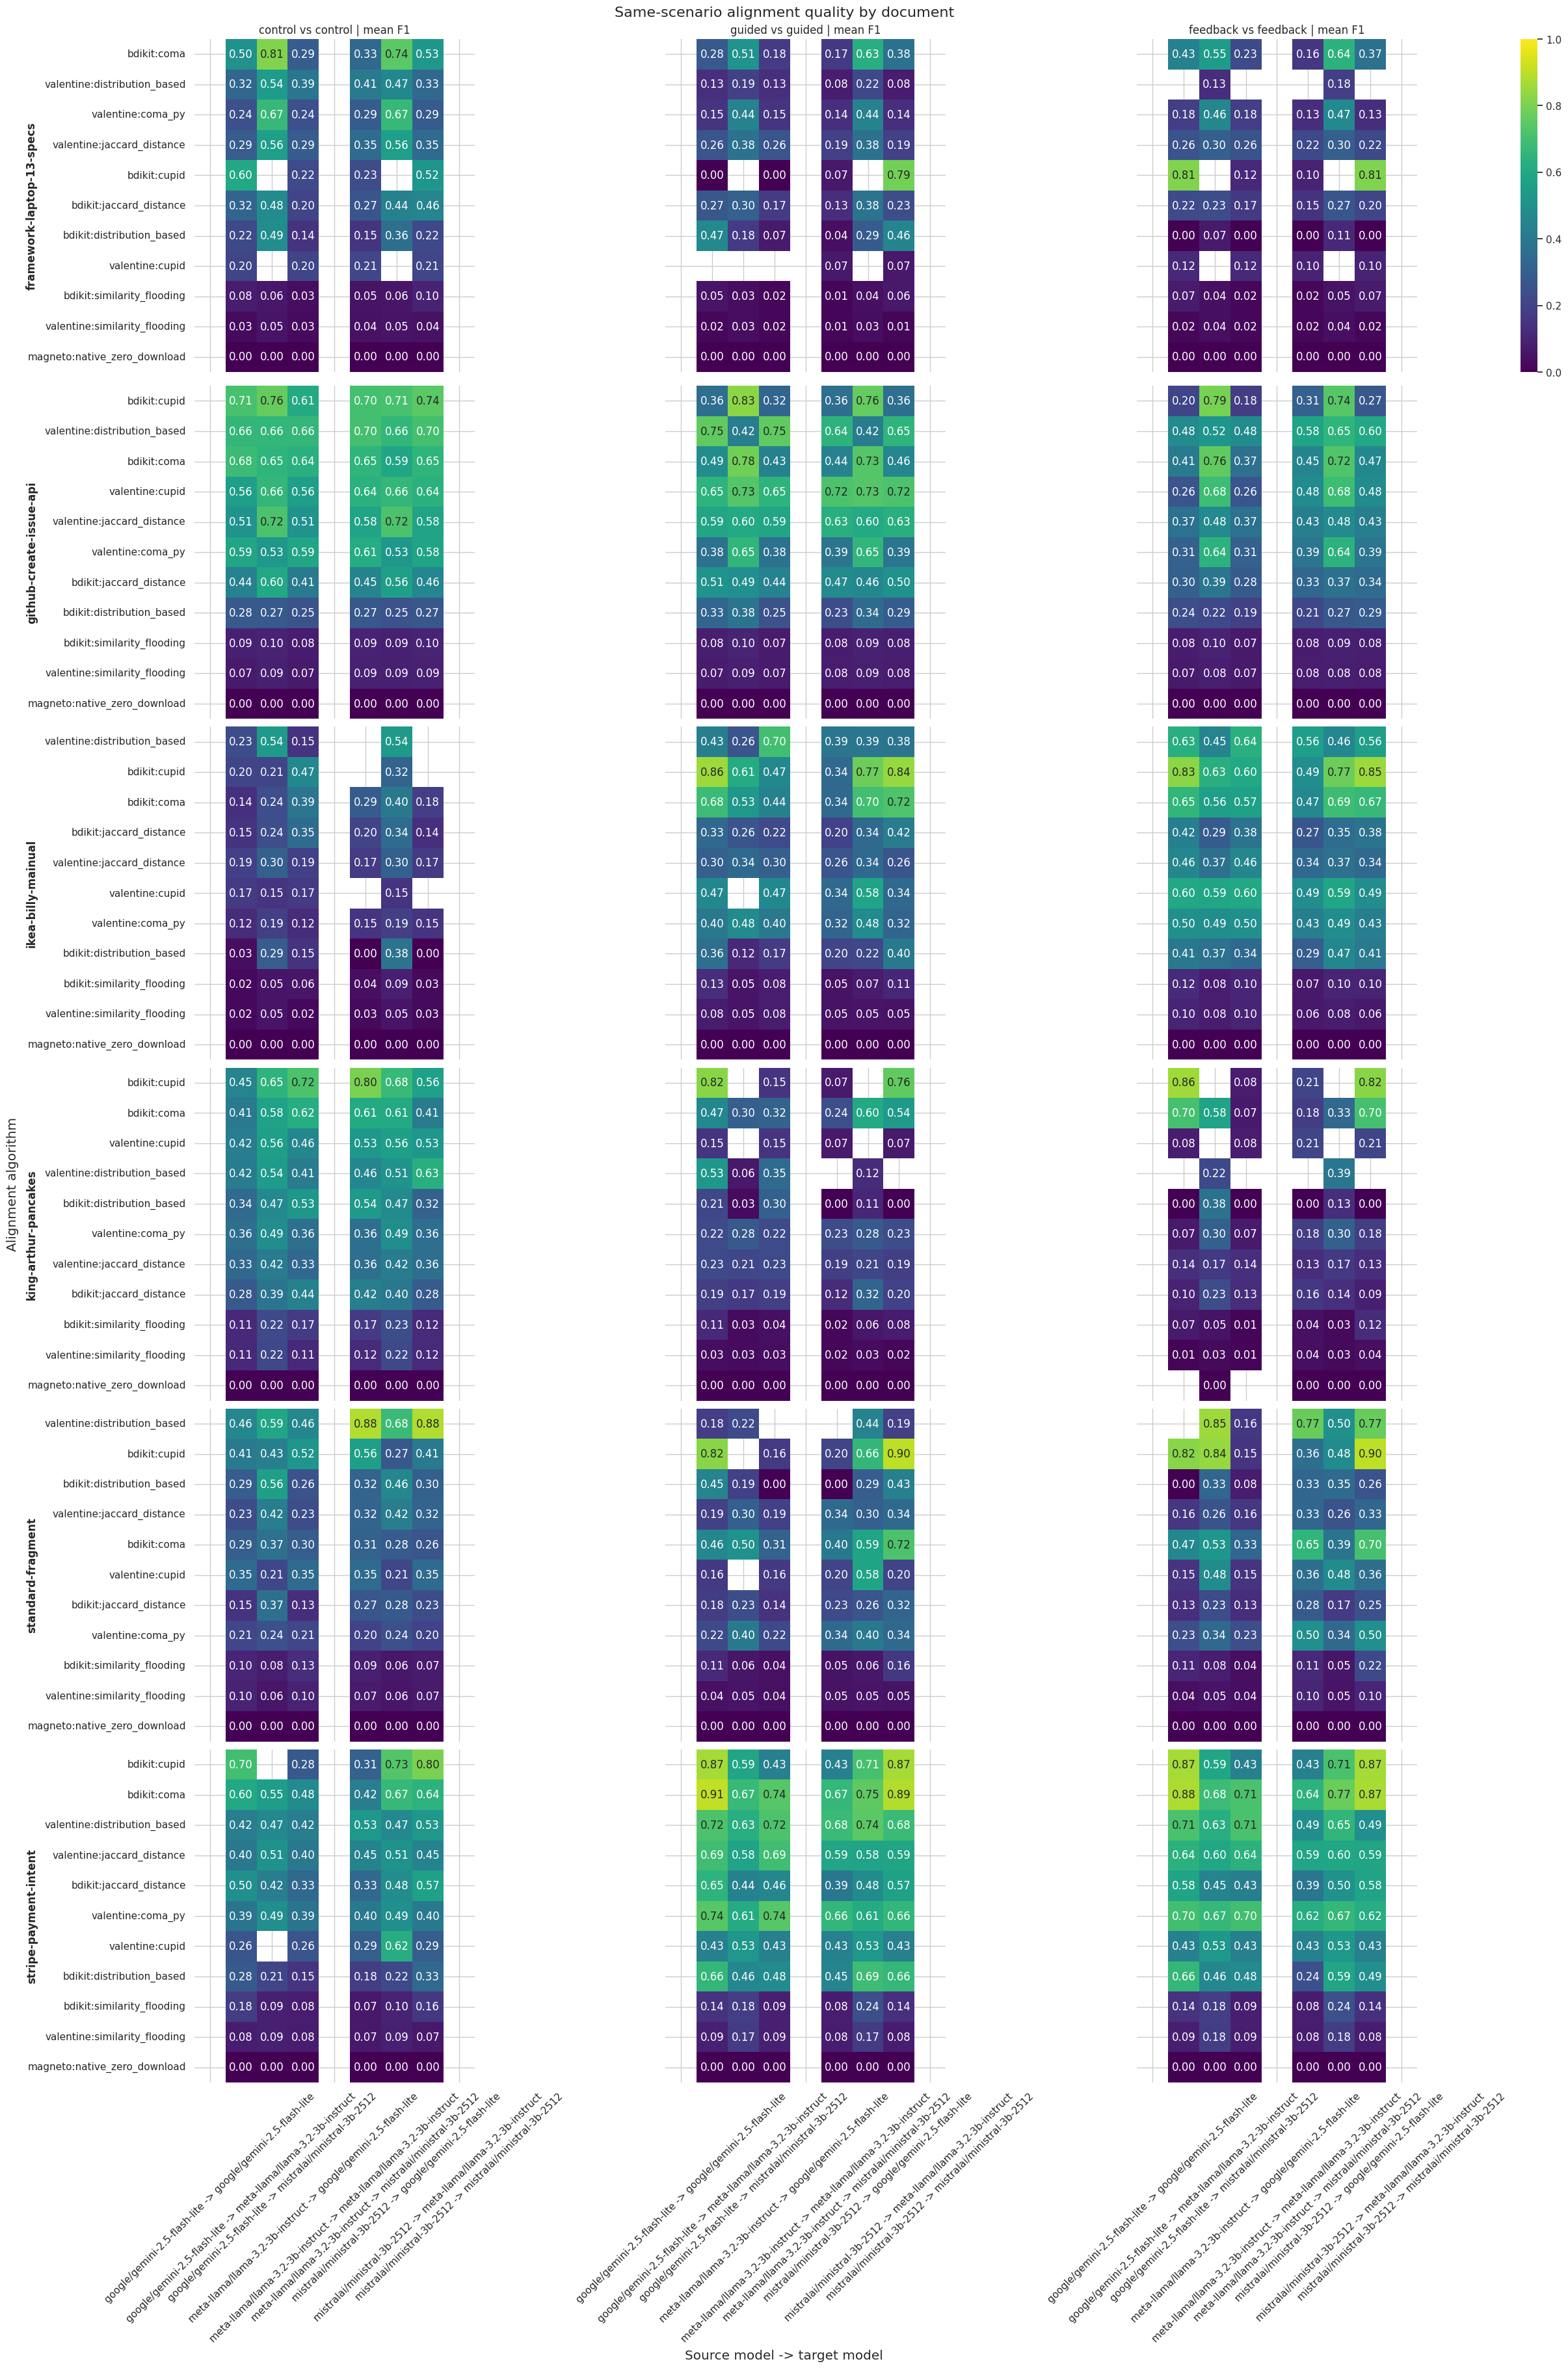

In [9]:
same_scenario_points = (
    pair_scores[
        pair_scores["source_condition"].astype(str)
        == pair_scores["target_condition"].astype(str)
    ]
    .assign(
        method_label=lambda df: df["backend"].astype(str) + ":" + df["method"].astype(str),
        model_pair_label=lambda df: (
            df["source_producer_id"].astype(str)
            + " -> "
            + df["target_producer_id"].astype(str)
        ),
    )
    .groupby(
        [
            "source_document_id",
            "source_condition",
            "source_producer_id",
            "target_producer_id",
            "model_pair_label",
            "backend",
            "method",
            "method_label",
        ],
        dropna=False,
    )
    .agg(mean_f1=("pair_alignment_f1", "mean"))
    .reset_index()
)
producer_order = sorted(
    set(same_scenario_points["source_producer_id"].astype(str).tolist())
    | set(same_scenario_points["target_producer_id"].astype(str).tolist())
)
pair_order = [
    f"{source_model} -> {target_model}"
    for source_model in producer_order
    for target_model in producer_order
]
scenario_order = ["control", "guided", "feedback"]
document_order = sorted(
    same_scenario_points["source_document_id"].astype(str).unique().tolist()
)
display({
    "same_scenario_rows": int(len(same_scenario_points)),
    "documents": document_order,
    "model_pair_order": pair_order,
})
document_method_orders = {}
document_row_heights = []
for document_id in document_order:
    document_frame = same_scenario_points[
        same_scenario_points["source_document_id"] == document_id
    ].copy()
    method_order = (
        document_frame[
            document_frame["source_condition"].astype(str) == "control"
        ]
        .groupby("method_label", dropna=False)["mean_f1"]
        .mean()
        .sort_values(ascending=False)
        .index.astype(str)
        .tolist()
    )
    remaining_methods = sorted(
        set(document_frame["method_label"].astype(str).tolist()) - set(method_order)
    )
    method_order = method_order + remaining_methods
    document_method_orders[document_id] = method_order
    document_row_heights.append(max(len(method_order), 1))

fig, axes = plt.subplots(
    nrows=len(document_order),
    ncols=3,
    figsize=(24, max(6, 0.55 * sum(document_row_heights))),
    squeeze=False,
    constrained_layout=True,
    gridspec_kw={"height_ratios": document_row_heights},
)
fig.suptitle("Same-scenario alignment quality by document", fontsize=16)
fig.supxlabel("Source model -> target model")
fig.supylabel("Alignment algorithm")

for row_index, document_id in enumerate(document_order):
    document_frame = same_scenario_points[
        same_scenario_points["source_document_id"] == document_id
    ].copy()
    method_order = document_method_orders[document_id]
    axes[row_index, 0].text(
        -0.58,
        0.5,
        document_id,
        transform=axes[row_index, 0].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )
    for col_index, scenario in enumerate(scenario_order):
        axis = axes[row_index, col_index]
        scenario_frame = document_frame[
            document_frame["source_condition"].astype(str) == scenario
        ].copy()
        heatmap = (
            scenario_frame.pivot_table(
                index="method_label",
                columns="model_pair_label",
                values="mean_f1",
                aggfunc="mean",
            )
            .reindex(index=method_order, columns=pair_order)
        )
        sns.heatmap(
            heatmap,
            annot=True,
            fmt=".2f",
            cmap="viridis",
            vmin=0.0,
            vmax=1.0,
            ax=axis,
            cbar=(row_index == 0 and col_index == len(scenario_order) - 1),
        )
        if row_index == 0:
            axis.set_title(f"{scenario} vs {scenario} | mean F1")
        else:
            axis.set_title("")
        axis.set_xlabel("")
        axis.set_ylabel("")
        if row_index == len(document_order) - 1:
            axis.tick_params(axis="x", labelrotation=45, labelbottom=True)
        else:
            axis.tick_params(axis="x", labelbottom=False)
        if col_index == 0:
            axis.tick_params(axis="y", labelleft=True)
        else:
            axis.tick_params(axis="y", labelleft=False)

plt.show()


{'same_scenario_global_rows': 198,
 'model_pair_order': ['google/gemini-2.5-flash-lite -> google/gemini-2.5-flash-lite',
  'google/gemini-2.5-flash-lite -> meta-llama/llama-3.2-3b-instruct',
  'google/gemini-2.5-flash-lite -> mistralai/ministral-3b-2512',
  'meta-llama/llama-3.2-3b-instruct -> google/gemini-2.5-flash-lite',
  'meta-llama/llama-3.2-3b-instruct -> meta-llama/llama-3.2-3b-instruct',
  'meta-llama/llama-3.2-3b-instruct -> mistralai/ministral-3b-2512',
  'mistralai/ministral-3b-2512 -> google/gemini-2.5-flash-lite',
  'mistralai/ministral-3b-2512 -> meta-llama/llama-3.2-3b-instruct',
  'mistralai/ministral-3b-2512 -> mistralai/ministral-3b-2512']}

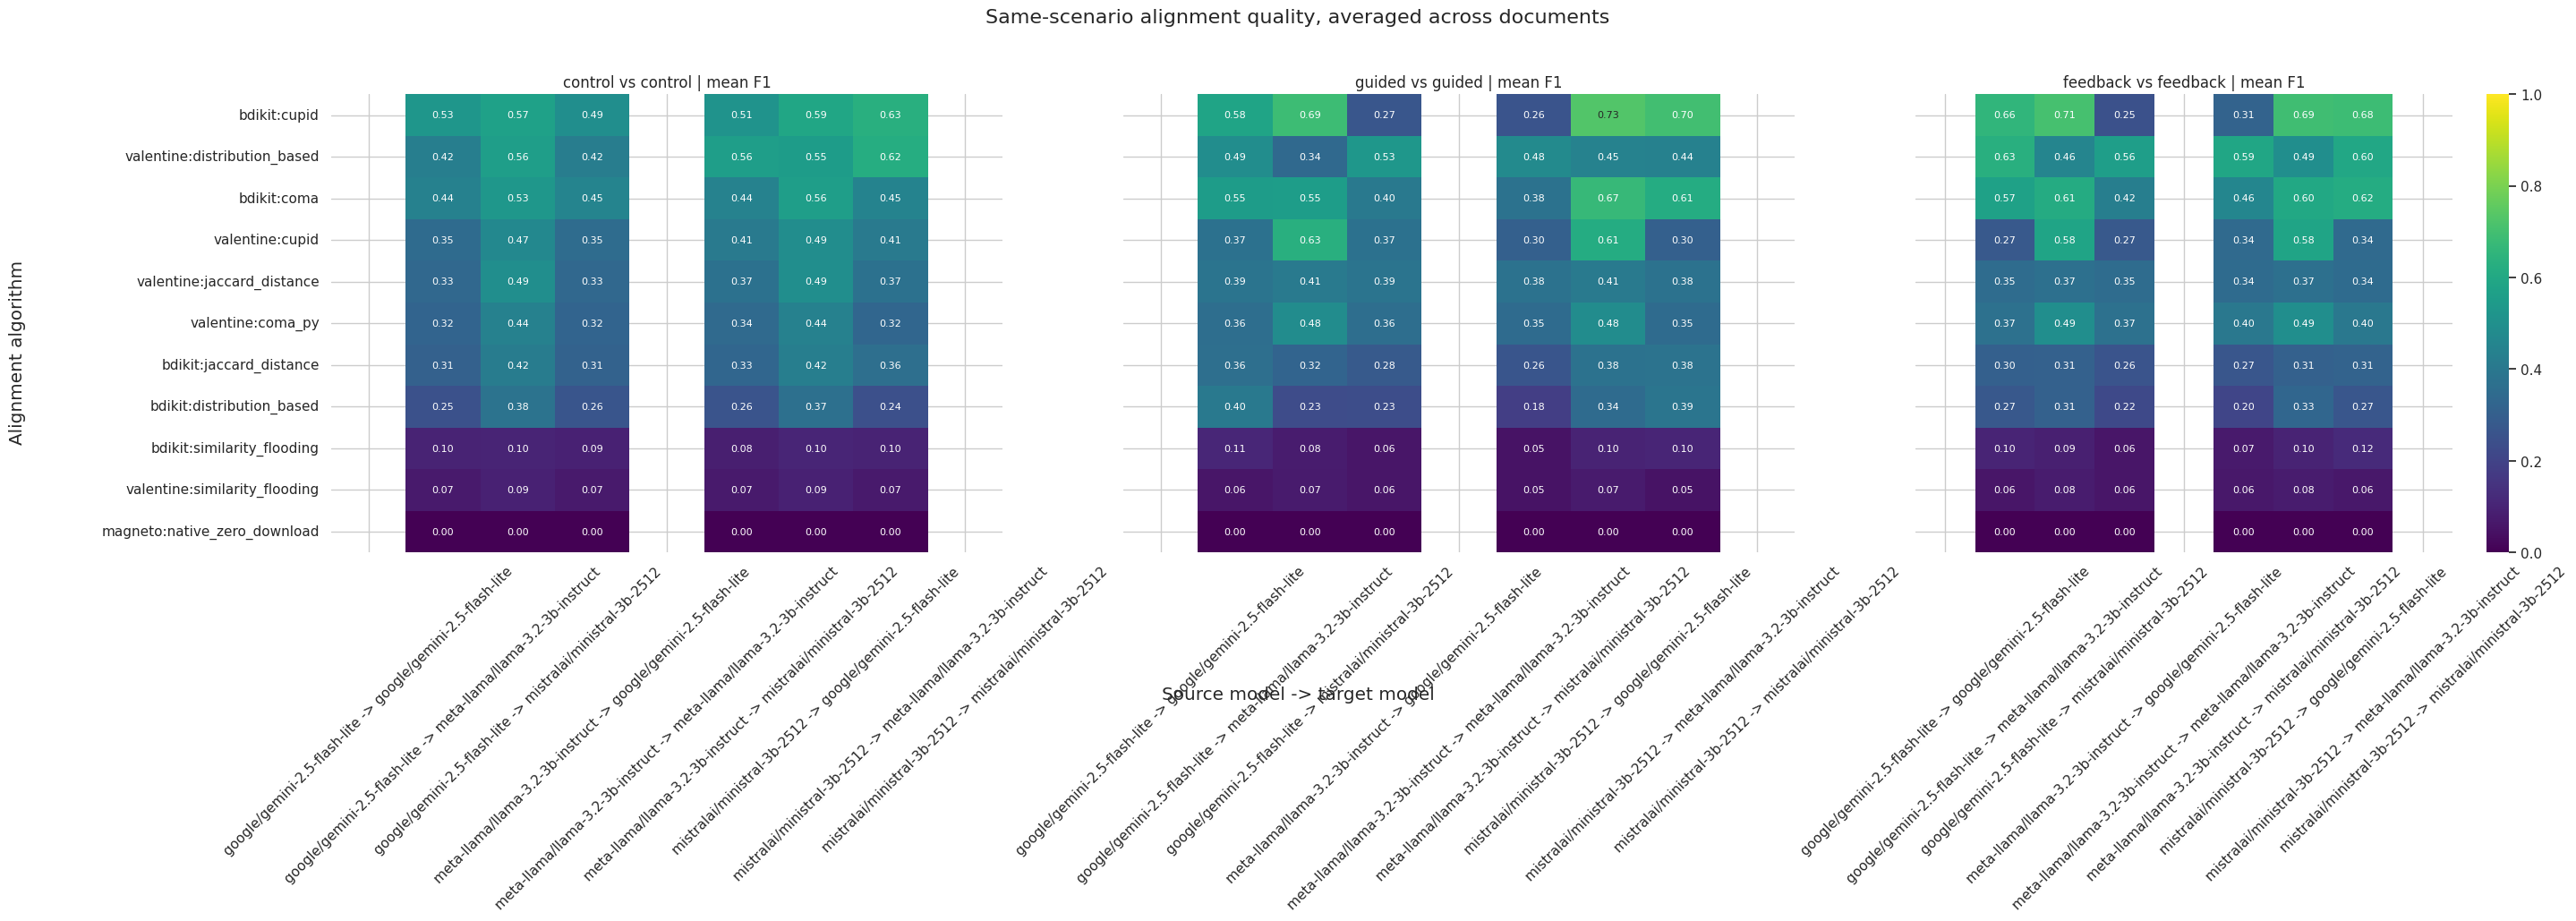

In [10]:
same_scenario_global_points = (
    pair_scores[
        pair_scores["source_condition"].astype(str)
        == pair_scores["target_condition"].astype(str)
    ]
    .assign(
        method_label=lambda df: df["backend"].astype(str) + ":" + df["method"].astype(str),
        model_pair_label=lambda df: (
            df["source_producer_id"].astype(str)
            + " -> "
            + df["target_producer_id"].astype(str)
        ),
    )
    .groupby(
        [
            "source_condition",
            "source_producer_id",
            "target_producer_id",
            "model_pair_label",
            "backend",
            "method",
            "method_label",
        ],
        dropna=False,
    )
    .agg(mean_f1=("pair_alignment_f1", "mean"))
    .reset_index()
)
producer_order = sorted(
    set(same_scenario_global_points["source_producer_id"].astype(str).tolist())
    | set(same_scenario_global_points["target_producer_id"].astype(str).tolist())
)
pair_order = [
    f"{source_model} -> {target_model}"
    for source_model in producer_order
    for target_model in producer_order
]
scenario_order = ["control", "guided", "feedback"]
method_order = (
    same_scenario_global_points[
        same_scenario_global_points["source_condition"].astype(str) == "control"
    ]
    .groupby("method_label", dropna=False)["mean_f1"]
    .mean()
    .sort_values(ascending=False)
    .index.astype(str)
    .tolist()
)
remaining_methods = sorted(
    set(same_scenario_global_points["method_label"].astype(str).tolist()) - set(method_order)
)
method_order = method_order + remaining_methods
display({
    "same_scenario_global_rows": int(len(same_scenario_global_points)),
    "model_pair_order": pair_order,
})
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(30, max(8, 0.55 * len(method_order))),
    squeeze=False,
)
fig.suptitle("Same-scenario alignment quality, averaged across documents", fontsize=16)
fig.supxlabel("Source model -> target model")
fig.supylabel("Alignment algorithm")
fig.subplots_adjust(left=0.14, right=0.98, bottom=0.22, top=0.86, wspace=0.18)
for col_index, scenario in enumerate(scenario_order):
    axis = axes[0, col_index]
    scenario_frame = same_scenario_global_points[
        same_scenario_global_points["source_condition"].astype(str) == scenario
    ].copy()
    heatmap = (
        scenario_frame.pivot_table(
            index="method_label",
            columns="model_pair_label",
            values="mean_f1",
            aggfunc="mean",
        )
        .reindex(index=method_order, columns=pair_order)
    )
    sns.heatmap(
        heatmap,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
        ax=axis,
        cbar=(col_index == len(scenario_order) - 1),
        annot_kws={"size": 8},
    )
    axis.set_title(f"{scenario} vs {scenario} | mean F1")
    axis.set_xlabel("")
    axis.set_ylabel("")
    axis.tick_params(axis="x", labelrotation=45, labelbottom=True)
    if col_index == 0:
        axis.tick_params(axis="y", labelleft=True)
    else:
        axis.tick_params(axis="y", labelleft=False)
plt.show()


{'same_scenario_algorithm_rows': 33, 'method_count': 11}

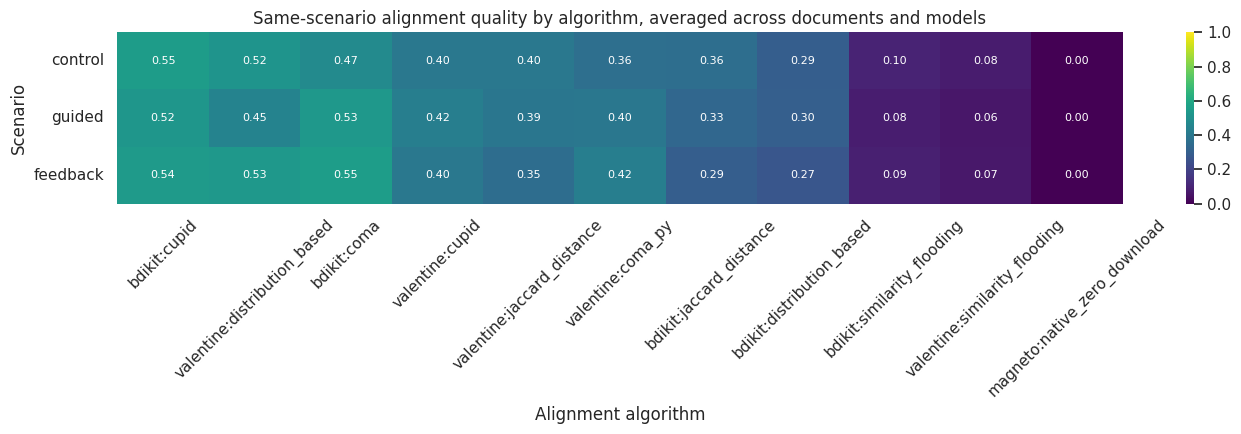

In [11]:
same_scenario_algorithm_points = (
    pair_scores[
        pair_scores["source_condition"].astype(str)
        == pair_scores["target_condition"].astype(str)
    ]
    .assign(
        method_label=lambda df: df["backend"].astype(str) + ":" + df["method"].astype(str)
    )
    .groupby(
        ["source_condition", "backend", "method", "method_label"],
        dropna=False,
    )
    .agg(mean_f1=("pair_alignment_f1", "mean"))
    .reset_index()
)
scenario_order = ["control", "guided", "feedback"]
method_order = (
    same_scenario_algorithm_points[
        same_scenario_algorithm_points["source_condition"].astype(str) == "control"
    ]
    .sort_values(["mean_f1", "method_label"], ascending=[False, True], ignore_index=True)["method_label"]
    .astype(str)
    .tolist()
)
remaining_methods = sorted(
    set(same_scenario_algorithm_points["method_label"].astype(str).tolist()) - set(method_order)
)
method_order = method_order + remaining_methods
display({
    "same_scenario_algorithm_rows": int(len(same_scenario_algorithm_points)),
    "method_count": int(len(method_order)),
})
heatmap = (
    same_scenario_algorithm_points.pivot_table(
        index="source_condition",
        columns="method_label",
        values="mean_f1",
        aggfunc="mean",
    )
    .reindex(index=scenario_order, columns=method_order)
)
fig, axis = plt.subplots(
    figsize=(max(14, 0.7 * len(method_order)), 4.5),
)
sns.heatmap(
    heatmap,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    ax=axis,
    annot_kws={"size": 8},
)
axis.set_title("Same-scenario alignment quality by algorithm, averaged across documents and models")
axis.set_xlabel("Alignment algorithm")
axis.set_ylabel("Scenario")
axis.tick_params(axis="x", labelrotation=45)
axis.tick_params(axis="y", labelrotation=0)
plt.tight_layout()
plt.show()
